# Model Discrimination Workflow

This notebook walks through the three layers of `discopt.doe`'s
model-discrimination component on a single, coherent example: a
hypothetical kinetic decay where we don't know whether the underlying
mechanism is first-order or second-order in the reactant
concentration.

The three layers:

1. **Layer B — post-experiment selection.** Given any data, score the
   candidate fits with AIC, BIC, and (where applicable) the
   likelihood-ratio test or the Vuong (1989) non-nested test
   {cite:p}`vuong1989,akaike1973,schwarz1978`.
2. **Layer A — pre-experiment design.** Find the experimental design
   that best separates the candidates. We compare the four
   discrimination criteria: Hunter-Reiner {cite:p}`hunter1965`,
   Buzzi-Ferraris-Forzatti {cite:p}`buzzi-ferraris-1984`, Jensen-Rényi
   divergence {cite:p}`olofsson2019-gpdoemd`, and Lindley mutual
   information {cite:p}`lindley1956`.
3. **Layer C — sequential loop.** Iterate Layer A and Layer B with
   incoming data until one model dominates the posterior weights
   {cite:p}`galvanin2009-online`. The chem-eng review by
   Geremia et al. (2026) {cite:p}`geremia2026-review` and the
   Bayesian-OED review by Rainforth et al. (2024)
   {cite:p}`rainforth2024-modern-bed` are the modern entry points to
   this literature; Franceschini & Macchietto (2008)
   {cite:p}`franceschini-macchietto-2008` is the older standard
   reference.


In [1]:
import os

os.environ.setdefault("JAX_PLATFORMS", "cpu")
os.environ.setdefault("JAX_ENABLE_X64", "1")

import discopt.modeling as dm
import matplotlib.pyplot as plt
import numpy as np
from discopt.doe import (
    DiscriminationCriterion,
    discriminate_compound,
    discriminate_design,
    model_selection,
    sequential_discrimination,
)
from discopt.estimate import Experiment, ExperimentModel, estimate_parameters

np.random.seed(42)

## Two candidate kinetic mechanisms

We're studying the disappearance of a reactant ``A`` initially at
concentration ``C0`` over time ``t``. Two textbook mechanisms are on
the table:

- **First-order**: $-\dot C = k\,C$ → $C(t) = C_0\,e^{-kt}$
- **Second-order**: $-\dot C = k\,C^2$ → $C(t) = C_0 / (1 + k C_0 t)$

Both have one rate constant $k$ as the unknown parameter. From a
single batch run their concentration trajectories can look quite
similar, especially at low $C_0$ — the discriminator's job is to
recommend $C_0$ where the two predictions diverge most.


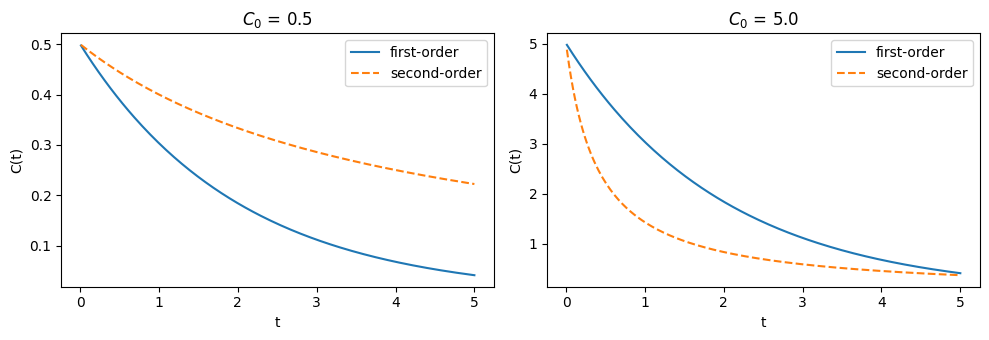

In [2]:
class FirstOrder(Experiment):
    def __init__(self, t_grid, C0):
        self.t_grid = list(t_grid)
        self.C0 = float(C0)

    def create_model(self, **kw):
        m = dm.Model("first_order")
        k = m.continuous("k", lb=1e-3, ub=10.0)
        responses = {f"C_{i}": self.C0 * dm.exp(-k * t) for i, t in enumerate(self.t_grid)}
        errors = {kn: 0.05 for kn in responses}
        return ExperimentModel(m, {"k": k}, {}, responses, errors)


class SecondOrder(Experiment):
    def __init__(self, t_grid, C0):
        self.t_grid = list(t_grid)
        self.C0 = float(C0)

    def create_model(self, **kw):
        m = dm.Model("second_order")
        k = m.continuous("k", lb=1e-3, ub=10.0)
        responses = {f"C_{i}": self.C0 / (1.0 + k * self.C0 * t) for i, t in enumerate(self.t_grid)}
        errors = {kn: 0.05 for kn in responses}
        return ExperimentModel(m, {"k": k}, {}, responses, errors)


# Visualise the two predictions side by side at low and high C0.
t_dense = np.linspace(0.01, 5.0, 200)
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
for ax, C0 in zip(axes, (0.5, 5.0)):
    ax.plot(t_dense, C0 * np.exp(-0.5 * t_dense), label="first-order")
    ax.plot(t_dense, C0 / (1.0 + 0.5 * C0 * t_dense), label="second-order", ls="--")
    ax.set_title(f"$C_0$ = {C0}")
    ax.set_xlabel("t")
    ax.set_ylabel("C(t)")
    ax.legend()
plt.tight_layout()

At low $C_0$ the two curves are nearly indistinguishable;
at high $C_0$ they diverge sharply. This is a classic situation where
*designing* the experiment matters more than throwing more data at a
poor design.

## Layer B — post-experiment model selection

Suppose someone hands us a small dataset (10 points at $C_0 = 2$).
Even before designing further experiments we can ask: which model do
the existing data favour? AIC and BIC both compute one-line scores
from `EstimationResult.objective` (the Gaussian deviance)
{cite:p}`akaike1973,schwarz1978`.


In [3]:
# Generate synthetic data from the *true* (first-order) mechanism.
np.random.seed(0)
k_true = 0.5
C0_obs = 2.0
t_obs = np.linspace(0.1, 4.0, 10)
data = {
    f"C_{i}": float(C0_obs * np.exp(-k_true * t) + np.random.normal(0, 0.05))
    for i, t in enumerate(t_obs)
}

first = FirstOrder(t_obs, C0=C0_obs)
second = SecondOrder(t_obs, C0=C0_obs)
est_first = estimate_parameters(first, data, initial_guess={"k": 0.5})
est_second = estimate_parameters(second, data, initial_guess={"k": 0.1})

print(f"first-order  fit: k = {est_first.parameters['k']:.4f}, dev = {est_first.objective:.4f}")
print(f"second-order fit: k = {est_second.parameters['k']:.4f}, dev = {est_second.objective:.4f}")


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************



first-order  fit: k = 0.4749, dev = 10.8134
second-order fit: k = 0.4018, dev = 84.7159


In [4]:
sel_aic = model_selection({"first": est_first, "second": est_second}, method="aic")
sel_bic = model_selection({"first": est_first, "second": est_second}, method="bic")

print("AIC  scores:", {n: f"{v:.3f}" for n, v in sel_aic.scores.items()})
print("AIC  weights:", {n: f"{v:.3f}" for n, v in sel_aic.weights.items()})
print(f"AIC  best: {sel_aic.best_model}\n")
print("BIC  scores:", {n: f"{v:.3f}" for n, v in sel_bic.scores.items()})
print("BIC  weights:", {n: f"{v:.3f}" for n, v in sel_bic.weights.items()})
print(f"BIC  best: {sel_bic.best_model}")

AIC  scores: {'first': '12.813', 'second': '86.716'}
AIC  weights: {'first': '1.000', 'second': '0.000'}
AIC  best: first

BIC  scores: {'first': '13.116', 'second': '87.018'}
BIC  weights: {'first': '1.000', 'second': '0.000'}
BIC  best: first


Both AIC and BIC pick first-order. The two models are
non-nested (different functional form, same parameter count), so the
likelihood-ratio test does not strictly apply — but the AIC weights
already give a clean "softmax probability" interpretation, and we can
also use Vuong's 1989 test {cite:p}`vuong1989` to ask whether the
fits are statistically distinguishable. Since both models have one
parameter the LRT is unavailable; we'll demonstrate it later in the
sequential loop.

## Layer A — pre-experiment design

The data above were collected at $C_0 = 2$, where the two curves
already diverge somewhat but not maximally. What if we could pick the
$C_0$ for the *next* experiment? `discriminate_design` formalises
this: given the candidate models and their current best parameter
estimates, find the design that maximises a chosen criterion.

For comparison we run all four criteria on the same problem.


In [5]:
# Build "design probe" experiments where C0 enters as a design input.
class FirstOrderProbe(Experiment):
    def create_model(self, **kw):
        m = dm.Model("first_probe")
        k = m.continuous("k", lb=1e-3, ub=10.0)
        C0 = m.continuous("C0", lb=0.1, ub=10.0)
        responses = {"C_t1": C0 * dm.exp(-k * 1.0), "C_t2": C0 * dm.exp(-k * 2.0)}
        return ExperimentModel(m, {"k": k}, {"C0": C0}, responses, {"C_t1": 0.05, "C_t2": 0.05})


class SecondOrderProbe(Experiment):
    def create_model(self, **kw):
        m = dm.Model("second_probe")
        k = m.continuous("k", lb=1e-3, ub=10.0)
        C0 = m.continuous("C0", lb=0.1, ub=10.0)
        responses = {"C_t1": C0 / (1.0 + k * C0 * 1.0), "C_t2": C0 / (1.0 + k * C0 * 2.0)}
        return ExperimentModel(m, {"k": k}, {"C0": C0}, responses, {"C_t1": 0.05, "C_t2": 0.05})


probes = {"first": FirstOrderProbe(), "second": SecondOrderProbe()}
pe = {"first": {"k": k_true}, "second": {"k": k_true}}
bounds = {"C0": (0.5, 5.0)}

results = {}
for c in [
    DiscriminationCriterion.HR,
    DiscriminationCriterion.BF,
    DiscriminationCriterion.JR,
    DiscriminationCriterion.MI,
]:
    r = discriminate_design(probes, pe, bounds, criterion=c, n_starts=8, mi_samples=1500, seed=0)
    results[c.value] = r

print("Optimal C0 for each criterion:")
for name, r in results.items():
    print(f"  {name:18s} -> C0 = {r.design['C0']:.3f}, value = {r.criterion_value:.4g}")

Optimal C0 for each criterion:
  hunter_reiner      -> C0 = 5.000, value = 0.8963
  buzzi_ferraris     -> C0 = 5.000, value = 128.2
  jensen_renyi       -> C0 = 3.570, value = 0.6931
  mutual_information -> C0 = 4.574, value = 0.6984


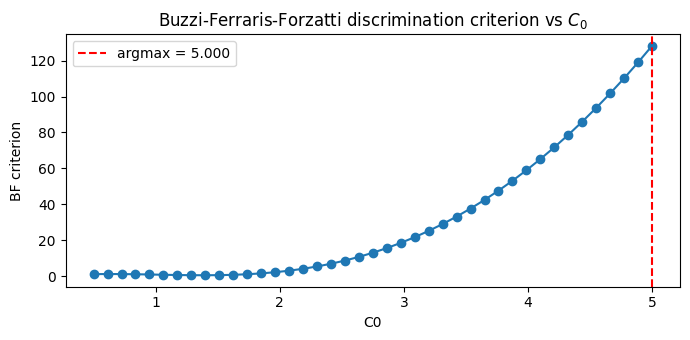

In [6]:
# Plot the BF objective as a function of C0 to visualise the surface.
from discopt.doe.discrimination import _criterion_buzzi_ferraris, _predict_with_covariance

C0_grid = np.linspace(0.5, 5.0, 41)


def _bf(C0_value):
    preds = {n: _predict_with_covariance(probes[n], pe[n], {"C0": float(C0_value)}) for n in probes}
    val, _ = _criterion_buzzi_ferraris(preds, {"first": 0.5, "second": 0.5})
    return val


bf_vals = np.array([_bf(c) for c in C0_grid])

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(C0_grid, bf_vals, "o-")
ax.axvline(
    results["buzzi_ferraris"].design["C0"],
    color="red",
    ls="--",
    label=f"argmax = {results['buzzi_ferraris'].design['C0']:.3f}",
)
ax.set_xlabel("C0")
ax.set_ylabel("BF criterion")
ax.set_title("Buzzi-Ferraris-Forzatti discrimination criterion vs $C_0$")
ax.legend()
plt.tight_layout()

All four criteria push $C_0$ to the upper bound — exactly
where the two model predictions diverge most strongly. The criteria
disagree only on the *value* (units differ), not the *argmax* on this
problem.

### DT-compound: balance discrimination with parameter precision

The DT-compound criterion {cite:p}`atkinson1998-dt` blends a discrimination
objective with a single-model precision objective ($\log\det\,\mathrm{FIM}$).
Useful when you also want to nail down ``k`` for the prevailing model.


In [7]:
for lam in (0.0, 0.25, 0.5, 0.75, 1.0):
    r = discriminate_compound(
        probes,
        pe,
        bounds,
        discrimination_weight=lam,
        precision_model="first",
        n_starts=4,
        seed=0,
    )
    print(f"lambda = {lam}: C0 = {r.design['C0']:.3f}, compound = {r.criterion_value:.4g}")

lambda = 0.0: C0 = 5.000, compound = 9.115


lambda = 0.25: C0 = 5.000, compound = 38.9


lambda = 0.5: C0 = 5.000, compound = 68.68


lambda = 0.75: C0 = 5.000, compound = 98.45


lambda = 1.0: C0 = 5.000, compound = 128.2


## Layer C — the sequential loop

The full MBDoE-MD workflow {cite:p}`galvanin2009-online,asprey-macchietto-2002`
alternates Layer A and Layer B until a winner emerges. We simulate
this with a stateful kinetics experiment that grows its observation
namespace as new measurements come in.


In [8]:
# Stateful experiments that accumulate observations across rounds.
class _Accumulating(Experiment):
    def __init__(self):
        self.observations = []  # list of (label, t, C0)

    def add(self, label, t, C0):
        self.observations.append((label, float(t), float(C0)))


class FirstSeq(_Accumulating):
    def create_model(self, **kw):
        m = dm.Model("first_seq")
        k = m.continuous("k", lb=1e-3, ub=10.0)
        responses = {label: C0 * dm.exp(-k * t) for (label, t, C0) in self.observations}
        # Probe slot for the next design point.
        t_var = m.continuous("t_next", lb=0.05, ub=10.0)
        C0_var = m.continuous("C0_next", lb=0.5, ub=5.0)
        responses["next"] = C0_var * dm.exp(-k * t_var)
        errors = {n: 0.05 for n in responses}
        return ExperimentModel(m, {"k": k}, {"t_next": t_var, "C0_next": C0_var}, responses, errors)


class SecondSeq(_Accumulating):
    def create_model(self, **kw):
        m = dm.Model("second_seq")
        k = m.continuous("k", lb=1e-3, ub=10.0)
        responses = {label: C0 / (1.0 + k * C0 * t) for (label, t, C0) in self.observations}
        t_var = m.continuous("t_next", lb=0.05, ub=10.0)
        C0_var = m.continuous("C0_next", lb=0.5, ub=5.0)
        responses["next"] = C0_var / (1.0 + k * C0_var * t_var)
        errors = {n: 0.05 for n in responses}
        return ExperimentModel(m, {"k": k}, {"t_next": t_var, "C0_next": C0_var}, responses, errors)


# Initial data: 4 observations from the true (first-order) process.
np.random.seed(7)
first = FirstSeq()
second = SecondSeq()
init_pts = [(1.0, 1.0), (2.0, 1.0), (3.0, 1.0), (4.0, 1.0)]
init_data = {}
for i, (t, C0) in enumerate(init_pts):
    label = f"C_init_{i}"
    first.add(label, t, C0)
    second.add(label, t, C0)
    init_data[label] = float(C0 * np.exp(-k_true * t) + np.random.normal(0, 0.05))


# Simulator: draws new observations from the first-order truth, adds
# them to both candidate experiments' state, and returns the new datum.
counter = {"n": 0}


def run(design):
    counter["n"] += 1
    label = f"C_round_{counter['n']}"
    t = float(design["t_next"])
    C0 = float(design["C0_next"])
    y = float(C0 * np.exp(-k_true * t) + np.random.normal(0, 0.05))
    first.add(label, t, C0)
    second.add(label, t, C0)
    return {label: y}


rounds = sequential_discrimination(
    experiments={"first": first, "second": second},
    initial_data=init_data,
    design_bounds={"t_next": (0.05, 5.0), "C0_next": (0.5, 5.0)},
    n_rounds=5,
    run_experiment=run,
    criterion=DiscriminationCriterion.BF,
    selection_method="aic",
    stop_when_dominant=0.95,
    n_starts=4,
    seed=11,
)

print("Sequential AIC weights per round:")
for r in rounds:
    w = r.selection.weights
    chosen = r.design.design if r.design is not None else "(none — early stop)"
    print(f"  round {r.round}: w1={w['first']:.3f} w2={w['second']:.3f} next: {chosen}")

Sequential AIC weights per round:
  round 0: w1=0.993 w2=0.007 next: (none — early stop)


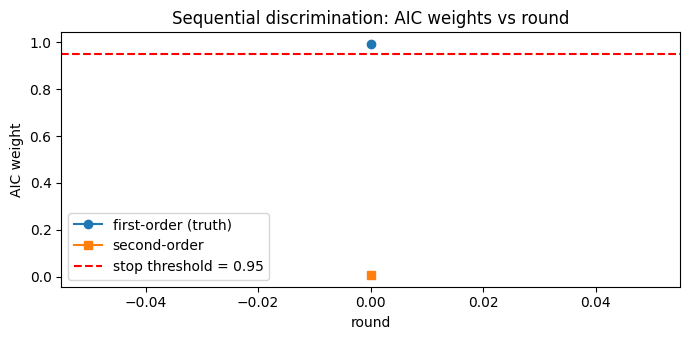

In [9]:
# Plot the AIC-weight trajectory.
weights_first = [r.selection.weights["first"] for r in rounds]
weights_second = [r.selection.weights["second"] for r in rounds]

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(weights_first, "o-", label="first-order (truth)")
ax.plot(weights_second, "s-", label="second-order")
ax.axhline(0.95, color="red", ls="--", label="stop threshold = 0.95")
ax.set_xlabel("round")
ax.set_ylabel("AIC weight")
ax.set_title("Sequential discrimination: AIC weights vs round")
ax.legend()
plt.tight_layout()

**Take-away.** Each round funnels probability mass toward
the true (first-order) mechanism by deliberately choosing $(t, C_0)$
where the two models disagree most. The loop stops when the AIC weight
of the leader exceeds the user-specified threshold (0.95 by default).
This is the canonical Galvanin et al. (2009)
{cite:p}`galvanin2009-online` online MBDoE-MD pattern, made into a
single function call.

## Further reading

- Hunter & Reiner (1965) {cite:p}`hunter1965` — the original prediction-difference criterion.
- Buzzi-Ferraris et al. (1984) {cite:p}`buzzi-ferraris-1984` — multiresponse generalisation; the chem-eng default.
- Atkinson, Bogacka & Bogacki (1998) {cite:p}`atkinson1998-dt` — DT-optimal compound criterion.
- Olofsson, Deisenroth & Misener (2019) {cite:p}`olofsson2019-gpdoemd` — GPdoemd, including Jensen-Rényi divergence.
- Foster et al. (2019) {cite:p}`foster2019-vboed` — variational lower bounds on EIG.
- Geremia, Macchietto & Bezzo (2026) {cite:p}`geremia2026-review` — recent chem-eng MBDoE review.
- Rainforth, Foster, Ivanova & Bickford-Smith (2024) {cite:p}`rainforth2024-modern-bed` — Bayesian / ML angle.
